# Parametric study of CO₂ conversion to hydrocarbons
Assignment 2  |  Chemical Reaction Engineering III  |  Ulm University  
  
Hendrik Jarosch, Hasan Babayev, Athithya Balasubbramanian  

## 1. Introduction

The catalytic hydrogenation of carbon dioxide (CO₂) into hydrocarbons presents a promising pathway for sustainable fuel production and greenhouse gas mitigation. By reacting CO₂ with hydrogen (H₂), valuable products such as methane (CH₄) and ethane (C₂H₆) can be synthesized. This process is particularly attractive when hydrogen is sourced from renewable energy, contributing to a sustainable circular carbon economy.[3]

The efficiency and selectivity of CO₂ hydrogenation are significantly influenced by operating conditions, including temperature, pressure, and feed composition. Understanding how these parameters affect the reaction outcomes is crucial for optimizing process performance. This study aims to evaluate these effects through a parametric analysis based on equilibrium calculations.

This report focuses on the catalytic conversion of CO₂ into hydrocarbons, specifically methane and ethane. The primary objective is to determine the equilibrium yield and product composition of these target hydrocarbons under varying operating conditions. The study examines the influence of temperature, pressure, and feed composition, particularly the CO₂/H₂ ratio, on the product distribution.

The approach involves establishing the relevant reaction network and identifying key components. Based on a selected inlet composition and assumed conversion, reaction extents and molar flow rates are calculated. Thermodynamic data are utilized to compute equilibrium constants, which are then combined with the reaction equations to evaluate the system behavior at equilibrium. By systematically varying the reaction conditions, the impact on hydrocarbon yield can be assessed.



## 2. Key reactions

The conversion of $CO_2$ to hydrocarbons involves several interrelated chemical reactions, including both direct $CO_2$ hydrogenation and intermediate steps involving $CO$ formation. The following reversible reactions are considered:
\begin{align}
CO_2 + 4H_2 &\rightleftharpoons CH_4 + 2H_2O \tag{1}\\
CO_2 + H_2 &\rightleftharpoons CO + H_2O \tag{2}\\
2CO + 5H2 &\rightleftharpoons C_2H_6 + 2H_2O \tag{3}\\
CO + 3H_2 &\rightleftharpoons CH_4 + H_2O \tag{4}
\end{align}

In reaction (1) an exothermic ($\Delta{H}^0$ = -164.9 kJ/mol) reaction is taking place where $CO_2$ is directly hydrogenated to methane and water. This is a key step in synthetic natural gas production. In reaction (2) $CO_2$ converts into $CO$ and water. This endothermic ($\Delta{H}^0$ = +41.2 kJ/mol) reaction acts as a preparatory step for $CO$-based hydrocarbon synthesis. Reaction (3) represents chain growth to ethane using $CO$ as a precursor. This exothermic ($\Delta{H}^0$ = -347.3 kJ/mol) reaction is central to the formation of longer-chain alkanes. Reaction (4) competes with reaction (3), converting $CO$ to methane. This exothermic ($\Delta{H}^0$ = -206.1 kJ/mol) reaction affects the distribution between methane and $C_2$+ products.

These reactions form the basis for the equilibrium model used in the study. They are assumed to occur simultaneously, and their interactions determine the final product composition under the given process conditions.

The equilibrium yields of methane and ethane from $CO_2$ hydrogenation are influenced by several factors:

Higher temperatures generally favor endothermic reactions, while lower temperatures favor exothermic reactions (e.g., methanation). Therefore, methane formation is favored at lower temperatures, whereas higher temperatures may promote $CO$ formation via RWGS (reverse water gas shift).

Increasing pressure typically favors reactions that result in a decrease in the number of gas molecules. Since methanation reactions reduce the total number of moles, higher pressures shift the equilibrium towards methane production.

The ratio of $CO_2$ to $H_2$ in the feed affects the equilibrium position. A higher $H_2$ concentration favors the formation of more reduced products like methane and ethane.

Understanding these dependencies is essential for optimizing reactor design and operating conditions to maximize hydrocarbon yields from $CO_2$ hydrogenation.  

At first, the matrix of stoichiometric coefficients $\underline{N}$ (equation 5) is set up and implemented. By finding its rank $R_N$, we find the number of key components and reactions.

$$
\underline{N}=
\begin{array}{c}
\begin{array}{cccc}
{\text{R}_1} & {\text{R}_2} & {\text{R}_3} & {\text{R}_4}
\end{array}
\\[0.1em]
\left[
\begin{array}{cccc}
-1 & -1 & 0  & 0  \\
0  & 1  & -2 & -1 \\
1  & 0  & 0  & 1  \\
0  & 0  & 1  & 0  \\
-4 & -1 & -5 & -3 \\
2  & 1  & 2  & 1
\end{array}
\right]
\end{array}
\quad
\begin{array}{c}
\\[0.3em]
{\text{CO}_2} \\
{\text{CO}}   \\
{\text{CH}_4} \\
{\text{C}_2\text{H}_6} \\
{\text{H}_2}  \\
{\text{H}_2\text{O}}
\end{array}
\tag{5}
$$

Below, the implementation in python is shown. In a following step, the matrix is divided by the rank into submatrices for which the order of reactants might need to be rearranged.

## 3. Construction and Analysis of the Stoichiometric Matrix

To systematically analyze the reaction network for CO₂ hydrogenation, we first construct the stoichiometric coefficient matrix, $\underline{N}$. Each row of this matrix corresponds to a chemical component (CO₂, CO, CH₄, C₂H₆, H₂, H₂O), and each column represents one of the four key reactions considered in this study. The entries in the matrix indicate the stoichiometric coefficients for each component in each reaction, with negative values for reactants and positive values for products.

In [2]:
import numpy as np                                           # import of numpy
from numpy.linalg import matrix_rank

# define matrix of stoichiometric coefficients
N_stoich = np.array([[-1, -1, 0, 0],  # CO2
                     [ 0,  1,-2,-1],  # CO
                     [ 1,  0, 0, 1],  # CH4
                     [-4, -1,-5,-3],  # H2
                     [ 0,  0, 1, 0],  # C2H6
                     [ 2,  1, 2, 1]]) # H2O

components = ['CO2', 'CO', 'CH4', 'H2', 'C2H6', 'H2O']        # list of participating components (order matches rows in N_stoich)

Rank_N = matrix_rank(N_stoich)                                # determination of the rank of the matrix of stoichiometric coefficients
print(r'Rank:',Rank_N)                                        # display key result

Rank: 3


The **rank** of the stoichiometric matrix, computed above, reveals the number of independent reactions in the system. The stoichiometric matrix was found to have a rank of $ R_N = 3 $.  This is a crucial step in reaction network analysis, as it determines the degrees of freedom and the minimum number of reactions required to describe the system completely. In this context, the rank helps identify which reactions are linearly independent.

By establishing the stoichiometric matrix and determining its rank, we lay the mathematical foundation for further equilibrium and yield calculations in the subsequent analysis.

So in our experimental setup we would like to choose the three key components to be $CO$ , $CO_2$ and $CH_4$. These substances are involved in all reactions and are considered as the primary carbon carriers in the system.  This decision simplifies the construction of the equilibrium model and makes it easier to trace carbon flow across the reaction network.

Since the rank of the stoichiometric matrix $R_N$ is known to be three, we can partition the matrix $\underline{N}$ into four submatrices:

$$
\underline{N}=
\begin{bmatrix}
    \underline{N}_{11} && \underline{N}_{12}\\
    &&\\
    \underline{N}_{21} && \underline{N}_{22}
\end{bmatrix}
\tag{6}
$$

Where:  
$\underline{N}_{11}$: square matrix of size 3×3, containing stoichiometric coefficients of the key components in the key reactions  
$\underline{N}_{11}$: invertible, as it has full rank  
$\underline{N}_{12}, \ \underline{N}_{21}, \ \underline{N}_{22}$: submatrices representing stoichiometry of non-key components and/or non-key reactions
</ul>

Whenever a new set of key components or reactions is selected, it's important to check the rank again using the reduced matrix. The new selection is only valid if the rank remains three, just like the original. The following code confirms that the matrix $\underline{N}_{11}$ still captures all the necessary stoichiometric relationships.

In [3]:
# split of the matrix of stoichiometric coefficients                                                  
N_11 = N_stoich[0:Rank_N, 0:Rank_N]                          # key reactions, key components (square matrix)
N_21 = N_stoich[Rank_N:N_stoich.shape[0], 0:Rank_N]          # key reactions, non-key components
N_12 = N_stoich[0:Rank_N, Rank_N:N_stoich.shape[1]]          # non-key reactions, key components
N_22 = N_stoich[Rank_N:N_stoich.shape[0], Rank_N:N_stoich.shape[1]] # non-key reactions and components

# validation of the rank of the submatrix (must be same as the overall rank)
rank_submatrix = matrix_rank(N_11)                           # determination of the rank of the submatrix
print("Submatrix with rank", rank_submatrix,":\n",N_11)      # display resulting rank        

Submatrix with rank 3 :
 [[-1 -1  0]
 [ 0  1 -2]
 [ 1  0  0]]


The stoichiometric matrix $\underline{N}$ serves as the basis for analyzing the equilibrium behavior of the CO₂ hydrogenation system. This matrix precisely encodes the molar relationships of all species involved in the specified reaction network. Four reactions with six components, including CO₂, CO, CH₄, C₂H₆, H₂, and H₂O, form reduced carbon products by direct and intermediate hydrogenation paths.

A rigorous rank analysis of the matrix generates a value of 3, meaning that only three reactions in the reaction set are linearly independent.  This outcome is crucial in thermodynamic modelling because it indicates the dimensionality of the reaction extent space.  In other words, the composition of the reacting system at equilibrium may be fully represented by the progression of three independent reactions, with the fourth being stoichiometrically dependent on the others.

To assist in the solution of the equilibrium system, appropriate key components were chosen.  CO₂, CO, and CH₄ were chosen for their involvement in all processes and as critical carbon carriers.  This choice not only provides mathematical solvability but also improves physical interpretability by tracking the redistribution of carbon between oxidized (CO₂, CO) and reduced (CH₄, C₂H₆) forms.

The matrix was then partitioned into block structures (N11, N21, N12, and N22) using traditional reaction network analysis methods.  The submatrix 𝑁11, including the stoichiometric coefficients of the key components in the independent reactions, was verified to be invertible, as anticipated by the complete rank.  This invertibility ensures that the relevant reaction extents are uniquely defined for every given set of component conversions, allowing for a stable and consistent formulation of the equilibrium problem.

## 4. Material Balance

To model the chemical conversion of CO₂ through various pathways, we apply the principle of molar balance using the concept of reaction extent (denoted as ${\xi}_j$). In matrix notation for a continuous system at steady-state [5], the molar balance is expressed as:

\begin{align}
  \underline{\dot n}_{out}-\underline{\dot n}_{in} =\Delta\underline{\dot n} = \underline{N}\,\underline{\dot\xi}\tag{7}
\end{align}

Where:  
$\underline{\Delta \dot{n}}$:  vector of net changes in molar flowrates of the components      
$\underline{N}$:     stoichiometric coefficient matrix (components × reactions)  
$\underline{\dot{\xi}}$:     vector of reaction extents (mol/s)
 

### 4.1 Conversion and flow rates

The conversion can be split into the conversion of the key components $\Delta\underline{\dot n}_{1}$ and that of the non-key components $\Delta\underline{\dot n}_{2}$:

\begin{equation}
  \Delta\underline{\dot n}=
    \begin{bmatrix}
      \Delta\underline{\dot n}_{1}\\
      \\
      \Delta\underline{\dot n}_{2}
    \end{bmatrix}%^1_2
    \tag{8}
\end{equation}

The conversion of the key components can easily be calculated with known values, e.g. from measurements as in equation 9. The length of respective vector $\Delta\underline{\dot n}_{1}$ equals $R_N$.

\begin{equation}
  \Delta\underline{\dot n}_{1} = \underline{\dot n}_{out, 1} - \underline{\dot n}_{in, 1}
  \tag{9}
\end{equation}

After some mathematical transformation, the conversion of the non-key components $\Delta\underline{\dot n}_{2}$ can be calculated according to:

\begin{equation}
  \Delta\underline{\dot n}_{2} = \underline{N}_{21}\,\underline{N}_{11}^{-1}\,\Delta\underline{\dot n}_{1}
  \tag{10}
\end{equation}

As an example we now assume that the following inlet molar flow rates (the components are also given in the second column for ease of understanding, though it is not correct mathematically):

\begin{equation}
  \underline{\dot n}_{in}=
    \begin{bmatrix}
      4.0 & CO_2\\ 1.0 & CO\\  0.5 & CH_4\\ 0.0 & C_2H_6\\ 20.0 & H_2\\ 2.0 & H_2O\\ 
    \end{bmatrix}
    \frac{mol}{s}
    \tag{11}
\end{equation}

The molar flow rates of the key components at the outlet is assumed to be known from measurements:

\begin{equation}
  \underline{\dot n}_{out, 1}=
    \begin{bmatrix}
      0.10 & CO_2\\ 0.02 & CO\\ 3.90 & CH_4
    \end{bmatrix}
    \frac{mol}{s}
    \tag{12}
\end{equation}

With these values the conversion of the non-key components and the outlet molar flow rates can be calculated based on the equations above. This is implemented as follows:

In [4]:
# inlet molar flow rates in mol/s
n_in = np.array([  [4.00],   # CO2
                   [1.00],   # CO
                   [0.50],   # CH4
                   [20.0],   # H2
                   [0.00],   # C2H6
                   [2.00]])  # H2O

# measured outlet molar flow rates of key components in mol/s
n_out1 = np.array([[1.00],   # CO2
                   [0.50],   # CO
                   [3.00]])  # CH4    

Delta_n1 = n_out1 - n_in[0:Rank_N]                            # calculate conversion of key_components from in- and outlet flow of key components
Delta_n2 = np.matmul(np.matmul(N_21, np.linalg.inv(N_11)), Delta_n1)     # calculate the conversion of non-key components

n_out =n_in + np.concatenate((Delta_n1, Delta_n2))            # outlet molar flow rates of all components

print('Delta_n2 in mol/s:\n',Delta_n2)                        # display Delta_n2 in mol/s
print('n_out in mol/s:\n',n_out)                              # display n_out    in mol/s

Delta_n2 in mol/s:
 [[-13. ]
 [  0.5]
 [  6.5]]
n_out in mol/s:
 [[1. ]
 [0.5]
 [3. ]
 [7. ]
 [0.5]
 [8.5]]


Now, from the cell output we have the following:
\begin{equation}
  \Delta\underline{\dot n}_{2}=
    \begin{bmatrix}
      -13.00 & \mathrm{C_2H_6}\\ 0.5 & \mathrm{H_2} \\ 6.5 &\mathrm{H_2O}
    \end{bmatrix}
    \frac{mol}{s}
    \tag{13}
\end{equation}


\begin{equation}
  \underline{\dot n}_{out}=
    \begin{bmatrix}
      1.00 & \mathrm{CO_2}\\ 0.5 & \mathrm{CO}\\ 3 & \mathrm{CH_4}\\ 7 & \mathrm{C_2H_6}\\ 0.5 & \mathrm{H_2}\\ 8.5 & \mathrm{H_2O}
    \end{bmatrix}
    \frac{mol}{s}
    \tag{14}
\end{equation}

Lastly, the reaction extent (equation 16) is obtained by solving the system of linear equations using a simplified version of equation (7), including only the key components and key reactions:
$$\Delta\underline{\dot n}_{1} = \underline{N}_{11} \underline{\dot \xi} \tag{15}$$

In [5]:
rxn_ext = np.linalg.solve(N_11, Delta_n1)                     # solve linear equation system
print('reaction extent xi in mol/s:\n',rxn_ext)               # display xi (rxn_ext) in mol/s

reaction extent xi in mol/s:
 [[2.5]
 [0.5]
 [0.5]]


\begin{equation}
  \underline{\dot \xi}=
    \begin{bmatrix}
      2.5 \\ 0.5 \\ 0.5
    \end{bmatrix}
    \frac{mol}{s}
    \tag{16}
\end{equation}

When a reaction occurs in forward direction, the reaction extend is identified positive. In this task, $\underline{\dot \xi}$ is estimated based on assumed values, that show a reduction of CO₂ and CO and therefore result in a net forward reaction.

### 4.2 Discussion of material balance

After developing the stoichiometric structure of the system, the next step is the determination of how far each independent reaction progresses.  This is carried out by applying the concept of reaction extent, which determines the conversion of compounds along every reaction path.  It provides a practical method for relating the system's stoichiometry to measurable flow rate variations.

Equation (7) illustrates how the difference between outlet and inlet molar flow rates is directly proportional to reaction extents via the stoichiometric matrix.  This system can only be solved with key components.  The measured or assumed flow changes are used as input to determine the reaction extents, as indicated in Equations (8) and (9).

Once reaction extents are determined, they could be used to compute the changes in flow rates of the remaining components, like C₂H₆, H₂ and H₂O.  This process is illustrated in Equation (10), which allows the whole outlet composition to be rebuilt from a limited set of known values.  The example in Equations (11) and (12) demonstrates this approach using specific molar flow data.

This technique is beneficial in multireaction systems: it minimises the number of unknowns by focusing just on the vital degrees of freedom and assures that all component balances are compatible with the stoichiometry.  Furthermore, it is directly related to thermodynamic modelling, as reaction extent is the fundamental parameter in equilibrium and energy-based calculations. For the modeling and study of the reaction extend in the second part of this assignment we can now focus on the key reactions determined and observed.

## 5. Thermodynamic data and considerations
To calculate the equilibrium constant, the heat capacity ($c_p$) , standard enthalpy ($H$), and standard entropy ($S$) of each reactant is needed. These properties depend on the temperature and thus need to be calculated by using an approximation. For **$\mathrm{CO}_2$**, **$\mathrm{CO}$**, **$\mathrm{H}_2$**, **$\mathrm{H_2O}$** and **$\mathrm{CH}_4$**, the Shomate equations were used as given below. The parameters are valid for a temperature range of 298–1300 K unless otherwise specified [6].

The Shomate equation for heat capacity, enthalpy and entropy are as follows:

$$
c_p = A + B\vartheta + C\vartheta^2 + D\vartheta^3 + E\vartheta^{-2}
\tag{16}
$$
$$
H-H(298.15 K) = \Delta_fH - \Delta_fH(298.15K) = A\vartheta + \frac{B\vartheta^2}{2} 
        + \frac{C\vartheta^3}{3}
        + \frac{D\vartheta^4}{4} - E\vartheta^{-1} + F - H
\tag{17}
$$
$$
S = A\ln(\vartheta) + B\vartheta + \frac{C\vartheta^2}{2} 
        + \frac{D\vartheta^3}{3}
        - \frac{E\vartheta^{-2}}{2} + G
\tag{18}
$$

$\mathbf{Table\,1:}$ Shomate parameters for $CO_2$, $CO$, $H_2$, $H_2O$ and $CH_4$ [6]:

| Species   | A        | B         | C          | D         | E         | F          | G         | H         |
|-----------|----------|-----------|------------|-----------|-----------|------------|-----------|-----------|
| CO₂       | 24.99735 | 55.18696  | -33.69137  | 7.948387  | -0.136638 | -403.6075  | 228.2431  | -393.5224 |
| CO        | 25.56759 | 6.096130  | 4.054656   | -2.671301 | 0.131021  | -118.0089  | 227.3665  | -110.5271 |
| H₂        | 33.06618 | -11.3634  | 11.43282   | -2.772874 | -0.158558 | -9.980797  | 172.70797 | 0.0       |
| H₂O (g)   | 30.09200 | 6.832514  | 6.793435   | -2.534480 | 0.082139  | -250.8810  | 223.3967  | -241.8264 |
| CH₄       | -0.70303 | 108.4773  | -42.52157  | 5.862788  | 0.678565  | -76.84376  | 158.7163  | -74.87310 |

However, the Shomate parameters for $\mathrm{C_2H_6}$ are not available in the NIST database. Therefore, in this work, the thermodynamic properties of $\mathrm{C_2H_6}$ were estimated using the Glenn equation (cf. equations 19–21). The coefficients were obtained by fitting the specific heat capacity data over the temperature range of 200–1000 K. The resulting Glenn parameters for $\mathrm{C_2H_6}$, rounded to four significant digits, are presented in Table 2:
\begin{equation}
    \frac{C^0_p(T)}{R} = a_1T^{-2}+a_2T^{-1}+a_3+a_4T^{1}+a_5T^{2}+a_6T^{3}+a_7T^{4} \tag{19}\\
\end{equation}

\begin{equation}
    \frac{H^0(T)}{RT} = -a_1T^{-2}+\frac{a_2ln(T)}{T}+a_3+\frac{a_4T^{1}}{2}+\frac{a_5T^{2}}{3}+\frac{a_6T^{3}}{4}+\frac{a_7T^{4}}{5}+\frac{b_1}{T} \tag{20}\\
\end{equation}

\begin{equation}
    \frac{S^0(T)}{R}=\frac{-a_1T^{-2}}{2}-a_2T^{-1}+a_3ln(T)+a_4T+\frac{a_5T^{2}}{2}+\frac{a_6T^{3}}{3}+\frac{a_7T^{4}}{4}+b_2 \tag{21}\\
\end{equation}

$\mathbf{Table\,2:}$ Glenn parameters for $C_2H_6$ rounded to four digits [7]:
| Species   | $a_1/10^5$       | $a_2/10^3$         | $a_3/10^1$          | $a_4/10^{-2}$         | $a_5/10^{-5}$         | $a_6/10^{-8}$          | $a_7/10^{-11}$         | $b_1/10^4$         | $b_2/10^2$ |
|-----------|----------|-----------|------------|-----------|-----------|------------|-----------|-----------|-----------|
| C₂H₆      |-1.862e+05 | 3.406e+03  | -1.952e+01  | 7.566e-02  | -8.204e-05 | 5.061e-08  | -1.319e-11  | -2.703e+04 | 1.298e+02 |

### 5.1 Implementation

The accurate calculation of thermodynamic properties such as heat capacity ($c_p$), enthalpy ($H$), and entropy ($S$) is essential for determining the Gibbs free energy and, ultimately, the equilibrium constant of a reaction. Since these properties vary with temperature, empirical equations fitted to experimental data are commonly used to estimate them over a given temperature range. [1]

For most gaseous species involved in CO₂ hydrogenation reactions, including CO₂, CO, H₂, H₂O, and CH₄, the **Shomate equation** is employed. This equation provides a reliable polynomial representation of $c_p$, $H$, and $S$ as functions of temperature. The parameters for these species are well-documented and available from the NIST Chemistry WebBook, making the Shomate equation a standard choice in thermodynamic modeling for these substances.

However, the **Shomate parameters for ethane (C₂H₆)** are not provided in the NIST database within the same temperature range. To estimate the thermodynamic properties of C₂H₆, the **Glenn equation** is used instead. The Glenn equation is also a polynomial expression fitted to temperature-dependent heat capacity data, and it allows for the computation of dimensionless forms of $c_p$, $H$, and $S$ over a wide temperature range.

Together, the Shomate and Glenn equations enable consistent and accurate estimation of thermodynamic properties for all components in the reaction system, which is crucial for calculating reaction enthalpy, entropy, and equilibrium constants as functions of temperature.

In [6]:
def prop_thermo(T, comp):
    """
    Calculates Cp, enthalpy and entropy for a given component using Shomate parameters.

    Parameters
    ----------
    T : float
        Temperature in °C
    comp : str
        Component name (e.g. 'H2')

    Returns
    -------
    results : np.ndarray
        Array with [Cp (J/mol/K), H (kJ/mol), S (J/mol/K)]
    """
    results = np.empty(3)                                         # generate empty vector of required size
    t = T / 1000                                                  # define the dimensionless temperature required
    R = 8.3145                                                    # define R in J/mol/K
    
    # define Shomate basis functions for cp, H and S
    fun_NIST_cp = np.array([t**0, t, t**2, t**3, t**-2, 0, 0, 0])
    fun_NIST_H  = np.array([t, t**2/2, t**3/3, t**4/4, -t**-1, 1, 0, -1])
    fun_NIST_S  = np.array([np.log(t), t, t**2/2, t**3/3, -t**-2/2, 0, 1, 0])
    # define NASA basis functions for cp, H and S
    fun_NASA_cp = np.array([T**-2, T**-1, 1, T, T**2, T**3, T**4, 0, 0])
    fun_NASA_H  = np.array([-T**-2, np.log(T)/T, 1, T/2, T**2/3, T**3/4, T**4/5, 1/T, 0])
    fun_NASA_S  = np.array([-T**-2/2, -T**-1, np.log(T), T, T**2/2, T**3/3, T**4/4, 0, 1])

    # define NIST/shomate parameters in dictionary (NASA/Glenn parameters for C2H6)
    shomate_params = {
        'CO2' : [24.99735, 55.18696, -33.69137, 07.948387, -0.136638, -403.6075, 228.2431, -393.5224],
        'CO'  : [25.56759, 6.096130, 04.054656, -2.671301, 00.131021, -118.0089, 227.3665, -110.5271],
        'H2'  : [33.06618, -11.3634, 011.43282, -2.772874, -0.158558, -9.980797, 172.7080, 00.000000],
        'H2O' : [30.09200, 6.832514, 06.793435, -2.534480, 00.082139, -250.8810, 223.3967, -241.8264],
        'CH4' : [-0.70303, 108.4773, -42.52157, 05.862788, 00.678565, -76.84376, 158.7163, -74.87310],
        'C2H6': [-1.862e+05, 3.406e+03, -1.952e+01, 7.566e-02, -8.204e-05, 5.061e-08, -1.319e-11, -2.703e+04, 1.298e+02] # NASA parameters
        
    }
    phys_param = np.array(shomate_params[comp])                            # select parameter set

    # Calculate properties using either NIST or NASA formulas
    if comp == 'C2H6':
        results[0] = fun_NASA_cp.dot(phys_param) * R                       # Cp in J/mol/K
        results[1] = fun_NASA_H.dot(phys_param) * R * T                    # H in J/mol
        results[2] = fun_NASA_S.dot(phys_param) * R                        # S in J/mol/K
    else:
        results[0] = fun_NIST_cp.dot(phys_param)                           # Cp in J/mol/K
        results[1] = (phys_param[-1] + fun_NIST_H.dot(phys_param)) * 1000  # H in J/mol
        results[2] = fun_NIST_S.dot(phys_param)                            # S in J/mol/K

    return results

# calculate and display results at 25 °C to check data
print('vector of c_p, H and S for CO2  at 25 °C:',prop_thermo(25+273, 'CO2')) 
print('vector of c_p, H and S for CO   at 25 °C:',prop_thermo(25+273, 'CO')) 
print('vector of c_p, H and S for CH4  at 25 °C:',prop_thermo(25+273, 'CH4')) 
print('vector of c_p, H and S for C2H6 at 25 °C:',prop_thermo(25+273, 'C2H6')) 
print('vector of c_p, H and S for H2   at 25 °C:',prop_thermo(25+273, 'H2')) 
print('vector of c_p, H and S for H2O  at 25 °C:',prop_thermo(25+273, 'H2O')) 

vector of c_p, H and S for CO2  at 25 °C: [ 3.71228316e+01 -3.93530889e+05  2.13768951e+02]
vector of c_p, H and S for CO   at 25 °C: [ 2.91490094e+01 -1.10528245e+05  1.97648216e+02]
vector of c_p, H and S for CH4  at 25 °C: [ 3.56434239e+01 -7.48772501e+04  1.86236764e+02]
vector of c_p, H and S for C2H6 at 25 °C: [ 5.24585228e+01 -8.38806923e+04  2.28947717e+02]
vector of c_p, H and S for H2   at 25 °C: [ 28.83630411  -4.17488536 130.66566737]
vector of c_p, H and S for H2O  at 25 °C: [ 3.35892490e+01 -2.41830912e+05  1.88818366e+02]


In [7]:
# define function with argument temperature
def rxn_data(T, reaction):
    """
    Calculates ΔCp, ΔH, ΔS, ΔG and K_eq for a given reaction at temperature T
    from stoichiometric matrix using parameters and equations defined in 'prop_therm'

    Parameters
    ----------
    T : float
        Temperature in °C
    reaction : int
        Reaction number (1-4)       
    Returns
    ----------
    res: np.ndarray
        Array with [ΔCp, ΔH, ΔS, ΔG, K_eq]
    """
    res = np.empty(5)                                                       # generate empty vector of required size
    data_CO     = prop_thermo(T, 'CO'  )
    data_CO2    = prop_thermo(T, 'CO2' )
    data_H2     = prop_thermo(T, 'H2'  )
    data_CH4    = prop_thermo(T, 'CH4' )
    data_H2O    = prop_thermo(T, 'H2O' )
    data_C2H6   = prop_thermo(T, 'C2H6')
    # use stoichiometry to calculate the thermodynamic properties of the reaction
    if reaction == 0:
        res[0] = 2*data_H2O[0] + data_CH4[0] - 4*data_H2[0] - data_CO2[0]   # reaction heat capacity
        res[1] = 2*data_H2O[1] + data_CH4[1] - 4*data_H2[1] - data_CO2[1]   # reaction enthalpy
        res[2] = 2*data_H2O[2] + data_CH4[2] - 4*data_H2[2] - data_CO2[2]   # reaction entropy
        res[3] = res[1] - T*res[2]                                          # reaction Gibbs enthalpy
        res[4] = np.exp(-res[3]/(8.3145*T))                                 # reaction equilibrium constant
    elif reaction == 1:
        res[0] = data_H2O[0] + data_CO[0] - data_H2[0] - data_CO2[0]        # reaction heat capacity
        res[1] = data_H2O[1] + data_CO[1] - data_H2[1] - data_CO2[1]        # reaction enthalpy
        res[2] = data_H2O[2] + data_CO[2] - data_H2[2] - data_CO2[2]        # reaction entropy
        res[3] = res[1] - T*res[2]                                          # reaction Gibbs enthalpy
        res[4] = np.exp(-res[3]/(8.3145*T))                                 # reaction equilibrium constant
    elif reaction == 2:
        res[0] = 2*data_H2O[0] + data_C2H6[0] - 5*data_H2[0] - 2*data_CO[0] # reaction heat capacity
        res[1] = 2*data_H2O[1] + data_C2H6[1] - 5*data_H2[1] - 2*data_CO[1] # reaction enthalpy
        res[2] = 2*data_H2O[2] + data_C2H6[2] - 5*data_H2[2] - 2*data_CO[2] # reaction entropy
        res[3] = res[1] - T*res[2]                                          # reaction Gibbs enthalpy
        res[4] = np.exp(-res[3]/(8.3145*T))                                 # reaction equilibrium constant
    return res

print(rxn_data(298.15, 0))
print(rxn_data(500, 1))
print(rxn_data(500, 2))

[-4.96510512e+01 -1.64998932e+05 -1.72583109e+02 -1.13543278e+05
  7.79528866e+19]
[-8.83897550e+00  3.98350862e+04  3.87199904e+01  2.04750909e+04
  7.26161757e-03]
[-5.76123019e+01 -3.60717096e+05 -4.79122928e+02 -1.21155632e+05
  4.53667463e+12]


To understand how temperature affects chemical equilibrium, we use thermodynamic properties such as **heat capacity ($c_p$)**, **enthalpy ($H$)**, **entropy ($S$)**, and **Gibbs free energy ($G$)**. These properties are first calculated for each species and then combined across the reaction using stoichiometry.

The change in **heat capacity** for a reaction is given by:

$$
\Delta_R c_p(T) = \sum_i \nu_i\, c_{p,i}(T) \tag{22}
$$

Here, $C_{p,i}(T)$ is the heat capacity of species *i* at temperature *T*, and $\nu_i$ is the stoichiometric coefficient (positive for products, negative for reactants). This tells us how the reaction's total heat capacity changes with temperature.

The **reaction enthalpy** is calculated as:

$$
\Delta_R H(T) = \sum_i \nu_i\, \Delta_f H_i(T) \tag{23}
$$

where $\Delta_f H_i(T)$ is the **standard enthalpy of formation** of species *i* at temperature *T*. This represents the total heat absorbed or released by the reaction.

Similarly, the **reaction entropy** is given by:

$$
\Delta_R S(T) = \sum_i \nu_i\, S_i(T)tag{24}
$$

where $S_i(T)$ is the **absolute entropy** of species *i*. This tells us how the disorder of the system changes during the reaction.

With both enthalpy and entropy, we can compute the **Gibbs free energy change** of the reaction:

$$
\Delta_R G(T) = \Delta_R H(T) - T\, \Delta_R S(T) \tag{25}
$$

Finally, the **equilibrium constant** at a given temperature is related to the Gibbs free energy by:

$$
K^\circ(T) = \exp\left(-\frac{\Delta_R G(T)}{R\,T}\right) \tag{26}
$$

This expression shows that a more negative $\Delta_R G$ leads to a larger equilibrium constant, meaning the reaction is more product-favored.

In this approach, the **thermodynamic properties are calculated for the entire reaction**, not just for the individual components. The component data (e.g., $c_p$, $H$, $S$) can be estimated using temperature-dependent equations like the **Shomate equations**, and functions such as `prop_thermo` are used to automate this process for multiple species and combine the values correctly based on stoichiometry.

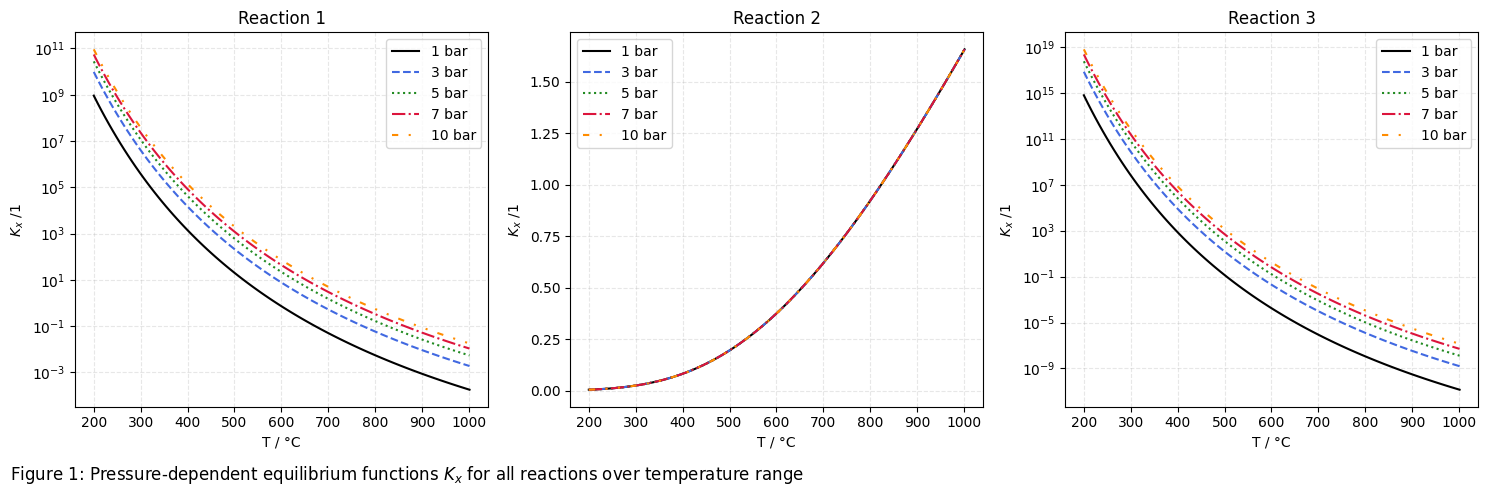

In [8]:
import matplotlib.pyplot as plt                                   # import of matplotlib

T = np.linspace(200 + 273.15, 1001 + 273.15, 100)                 # vector for temperature ranges (in K) 
p = np.linspace(1, 10, 5)                                         # vector for total pressure ranges (in bar)

rxns  = np.arange(N_11.shape[0])                                  # get number of reactions from N_11
delta_n = - np.sum(N_stoich, axis=0)[:N_11.shape[0]]              # get delta_n through summing over components and cut off 4th reaction

# calculate K_x for all reactions using equations 28 -31
K_x = np.empty([p.shape[0],T.shape[0],N_11.shape[0]])              # empty vector of shape: [reaction, pressure, temperature]

for i in range(T.shape[0]):
    for j in range(len(rxns)):
        rxn_data_get = rxn_data(T[i],rxns[j]) # call the function for thermodynamic data of the reaction
        K_eq = rxn_data_get[-1] # the last element in the results vector provides the thermodynamic equilibrium constant
        K_x[:,i,j] = K_eq * p ** delta_n[j] # calculate K_x at each temperature for all pressures

colors  = ['black', 'royalblue', 'forestgreen', 'crimson', 'darkorange', 'mediumvioletred']  # use destinct colors for each pressure
linestyles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5, 1, 5)), (0, (5, 2))] # use destinct linestyles
labels = [f'{int(val)} bar' for val in p]                         # get legend labels from pressure-array

# generate plot: 2x2 Subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for rxn_idx in range(len(rxns)):                                  # loop over reactions
    for j in range(len(p)):                                       # loop over pressure levels
        axs[rxn_idx].plot(T - 273.15, K_x[j, :, rxn_idx], color=colors[j], linestyle=linestyles[j], label=labels[j]) # plot K_x vs. T
    axs[rxn_idx].set_xlabel("T / °C")                             # add axis labels
    axs[rxn_idx].set_ylabel(r"$K_x$ /1")
    axs[rxn_idx].set_title(f"Reaction {rxn_idx + 1}")             # add plot title
    axs[rxn_idx].grid(True, linestyle='--', alpha=0.3)            # add gridlines
    if rxn_idx in [0, 2]:
        axs[rxn_idx].set_yscale("log")                            # logarithmic scale
    axs[rxn_idx].legend(loc='best')                               # add legend

fig.text(0.01, 0.03, 'Figure 1: Pressure-dependent equilibrium functions $K_x$ for all reactions over temperature range',
         ha='left', fontsize=12)                                  # add caption
plt.tight_layout(rect=[0, 0.06, 1, 1])                            # adjust layout to fit caption
plt.savefig("A2_Kx_Temp_Press.png", dpi=300, bbox_inches='tight') # save figure
plt.show()

### 5.2 Discussion of the equilibrium constants

Figure 1 depicts the temperature dependence of the mole-fraction-based equilibrium constants $K_x$ for reactions 1–3, as determined over a range of total pressures.  Every line illustrates a different pressure level, emphasizing the impact of pressure on the equilibrium position at various temperatures.

As predicted from the laws of thermodynamics, the equilibrium constants are extremely sensitive to temperature, especially in the range where the direction of heat transfer affects the favorability of the reactions.  The highly exothermic methanation reaction (Reaction 1) displays a rapid reduction in $K_x$ as temperature increases.  This pattern demonstrates that lower temperatures boost methane production, but higher temperatures shift the equilibrium towards the reactants.

On the other hand, the reverse water-gas shift reaction (Reaction 2), which is endothermic, demonstrates increasing equilibrium constants as temperature increases.  This behavior is consistent with the hypothesis that endothermic processes become more favorable as thermal energy rises.  The exothermic ethane production path (Reaction 3) shows a stronger temperature sensitivity than reaction 1, as seen by a similar but more dramatic fall in $K_x$.

Pressure effects are most visible in the vertical separation of the curves at various pressures.  In reactions 1 and 3, where the number of moles decreases (negative $\Delta{n}$), an increase in pressure shifts the equilibrium to the product side, resulting in larger $K_x$ values at a given temperature.  This pressure dependency becomes less noticeable at higher temperatures, when the temperature has more impact than pressure.

In gas-phase chemical reactions, the **equilibrium constant** quantifies the ratio of products to reactants when the reaction reaches equilibrium. Depending on how the reacting species are represented, the equilibrium constant can be expressed in different forms:

- **Pressure-based form** ($K^\circ$) uses the partial pressures of gases relative to a standard pressure ($p^\circ$).
- **Mole fraction form** ($K_x$) uses the mole fractions of each species in the gas mixture.

The relation between the two depends on the net change in moles of gas ($\Delta\nu$) during the reaction. When converting from pressure-based to mole-fraction-based expressions, the total system pressure ($p$) must be considered:

$$
K_x = K^\circ \left( \frac{p}{p^\circ} \right)^{\Delta\nu}
$$

This correction accounts for how total pressure affects the position of equilibrium. The following equations apply this principle to various reactions involving gases like CH₄, CO₂, CO, H₂, H₂O, and C₂H₆, commonly encountered in catalytic processes and synthesis gas chemistry.

$$K^° = \prod_i\left(\frac{p_i}{p^°}\right)^{\nu_i} \tag{26}$$
$$K_x = \prod_i x_i^{\nu_i} \tag{27}$$


$$K_{x,1} = \frac{x_{CH4 } \, x_{H2O}^2} {x_{CO2}   \, x_{H2}^4} = K_1^° \, \left(\frac{p}{p_0}\right)^2 \tag{28} $$
$$K_{x,2} = \frac{x_{CO  } \, x_{H2O}  } {x_{CO2}   \, x_{H2}  } = K_2^° \tag{29} $$
$$K_{x,3} = \frac{x_{C2H6} \, x_{H2O}^2} {x_{CO }^2 \, x_{H2}^5} = K_3^° \, \left(\frac{p}{p_0}\right)^3 \tag{30} $$
$$K_{x,4} = \frac{x_{CH4 } \, x_{H2O}  } {x_{CO }   \, x_{H2}^3} = K_4^° \, \left(\frac{p}{p_0}\right)^2 \tag{31} $$


These formulas link mole fraction-based equilibrium constants $𝐾_{x}$ to standard pressure-based constants 𝐾^0, allowing for variations in total moles of gas in each reaction through pressure correction terms.  For reactions with a net change in mole number ($\Delta n = 0$), pressure dependency becomes crucial and must be considered when predicting equilibrium compositions under different operating conditions.  This formulation integrates thermodynamic data with practical reactor conditions, allowing the equilibrium model to account for the impact of total pressure on product distribution.  These relationships are the foundation of the equilibrium estimation framework used in the following parametric analysis.

## 6. Parametric Study: Purpose and Operating Conditions

A **parametric study** helps us understand how different operating conditions affect the performance of a chemical process. In this case, we're studying the hydrogenation of CO₂ to form useful products like methane (CH₄), ethane (C₂H₆), and carbon monoxide (CO). The aim is to see how changes in temperature, pressure, and the ratio of reactants influence the amount of CO₂ that reacts, the types of products formed, and how efficient the process is overall.

We vary three main parameters in this study:

- **Temperature** is changed to understand how heat affects the reactions. Methanation reactions (which produce CH₄) are exothermic, meaning they release heat and are favored at lower temperatures. On the other hand, the reverse water-gas shift (RWGS) reaction is endothermic, meaning it needs heat to proceed and becomes more active at higher temperatures.

- **Pressure** is adjusted to see how it affects the balance between reactants and products. Reactions like methanation result in fewer gas molecules, so increasing pressure pushes the reaction toward forming more products (according to Le Chatelier’s principle).

- **CO₂/H₂ feed ratio** is changed to understand how the mixture of the two gases influences the outcome. Different ratios can lead to different products, so adjusting this helps us control what is formed in the reactor.

The operating conditions for kathalytic methanation proposed in the following are used in industrial applications [10]:

- The **temperature range** used here is **250–1000 °C**. Below 250 °C, reactions slow down too much. Between 250–350 °C, methanation is strong and produces a lot of CH₄. At 400 °C, the RWGS reaction becomes more important and produces more CO instead of CH₄. The temperature range was extended to 1000 °C in order to better study ethane production.

- The **pressure range** is **5 to 30 bar**, which is typical for processes like the Sabatier reaction and Power-to-Gas systems. Higher pressures help methanation reactions by shifting the equilibrium toward fewer gas molecules.

This parametric study helps us learn how each condition affects the CO₂ hydrogenation process. By doing this, we can find the best combination of temperature, pressure, and feed ratio to get the highest conversion and best product selectivity for industrial use.

### 6.1 Mole Balance Equation

The equation below represents a **mole balance** for a species involved in a chemical reaction:

$$
\dot{n}_{i,\text{out}} = \dot{n}_{i,\text{in}} + \nu_i\,\xi \tag{32}
$$

This expression is used to calculate how the amount of each chemical species changes as a result of the reaction. Here's what each term means:

$\dot{n}_{i,\text{in}}$: the **inlet molar flow rate** of species *i* (how many moles per second enter the system)

$\dot{n}_{i,\text{out}}$: the **outlet molar flow rate** of species *i* (how many moles per second leave the system)

$\nu_i$: the **stoichiometric coefficient** of species *i* (positive for products, negative for reactants)

$\xi$: the **extent of reaction** (measured in moles per second)

The extent of reaction, $\xi$, tells us how far the reaction has proceeded. For each mole of reaction that occurs, the amount of each species changes according to its stoichiometric coefficient.

This mole balance is widely used in chemical reactor design to track how reactants are consumed and products are formed inside a continuous-flow reactor like a plug flow or CSTR.

C:\Users\PC\AppData\Local\Temp\ipykernel_20256\1249792214.py:43: RuntimeWarning: invalid value encountered in log
  res[1] = np.log(x[1]) + np.log(x[5]) - np.log(x[0]) - np.log(x[3]) - np.log(K_x[1])
C:\Users\PC\AppData\Local\Temp\ipykernel_20256\1249792214.py:45: RuntimeWarning: invalid value encountered in log
  res[2] = np.log(x[4]) + 2 * np.log(x[5]) - 2 * np.log(x[1]) - 5 * np.log(x[3]) - np.log(K_x[2])
C:\Users\PC\AppData\Local\Temp\ipykernel_20256\1249792214.py:41: RuntimeWarning: invalid value encountered in log
  res[0] = np.log(x[2]) + 2 * np.log(x[5]) - np.log(x[0]) - 4 * np.log(x[3]) - np.log(K_x[0])


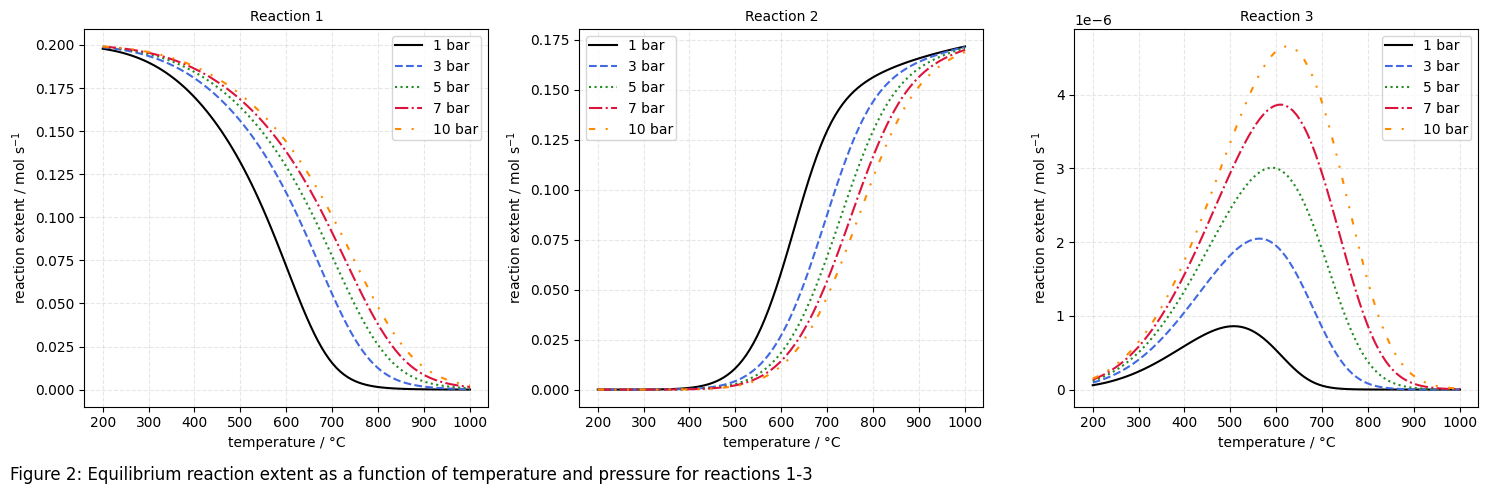

In [9]:
from scipy.optimize import root                                  # import numerical solver 

def composition(xi, n_in):
    """ calculates the molar fractions at equilibrium for a given reaction extent.
    Parameters:
        xi       - reaction extend (scalar)
        n_in     - inlet molar flows (array of length = number of components)
    Returns:
        x        - molar fractions of all components after reaction (array)
    """
    n_out = n_in + np.dot(N_stoich[:, :Rank_N], xi)               # compute outlet molar flows [mol/s]
    x = n_out / np.sum(n_out)                                     # convert to molar fractions 
    return x

def rxn_ext(xi, n_in, T, p):
    """ system of non-linear equations for equilibrium (must be zero at equilibrium). 
    Parameters: 
        xi         - reaction extents (array)
        n_in       - inlet molar flows (array of length = number of components) [mol/s]
        T          - temperature in K
        p          - pressure in bar
        N_stoich   - stoichimetric matrix (components x reactions)
        components - list of component names (list)
    Returns:
        res        - residual of equilibrium equation (array)
    """
    x = composition(xi, n_in)                                     # get outlet molar fractions
    n_rxns = N_11.shape[0]                                        # get number of reactions from N_11
    rxn_data_get = [rxn_data(T, rxns[j]) for j in range(len(rxns))]  # get data from function for each reaction
    
    K_eq = np.empty(n_rxns)                                       # create empty arrays
    K_x = np.empty(n_rxns)
    res = np.empty(n_rxns)
        
    for i in range(n_rxns):
        K_eq[i] = rxn_data_get[i][-1]                             # get K_eq values
        K_x[i] = K_eq[i] * p ** delta_n[i]                        # apply pressure exponents for each reaction

    # Calculate residuals for each reaction
    # Reaction 1: CO2 + 4 H2 <-> CH4 + 2 H2O
    res[0] = np.log(x[2]) + 2 * np.log(x[5]) - np.log(x[0]) - 4 * np.log(x[3]) - np.log(K_x[0])
    # Reaction 2: CO2 + H2 <-> CO + H2O
    res[1] = np.log(x[1]) + np.log(x[5]) - np.log(x[0]) - np.log(x[3]) - np.log(K_x[1])
    # Reaction 3: 2 CO + 5 H2 <-> C2H6 + 2 H2O
    res[2] = np.log(x[4]) + 2 * np.log(x[5]) - 2 * np.log(x[1]) - 5 * np.log(x[3]) - np.log(K_x[2])
    return res

n_rxns = N_11.shape[0]                                            # get number of key reactions
n_in = np.array([0.2, 0, 0, 0.8, 0, 0])                           # set inlet molar flow rates as example in stoichiometric ratio of the key reactions in mol s^-1
xi_0 = np.empty([p.shape[0],T.shape[0]])
xi_1 = np.empty([p.shape[0],T.shape[0]])
xi_2 = np.empty([p.shape[0],T.shape[0]])
xi_guess = np.array([0.001,0.001,0.0001])

for TT in range(T.shape[0]):                                      # vary temperature; range given above
    #print("Versuch:", TT)
    T_val = T[TT]
    for pp in range(p.shape[0]):                                  # vary pressure; range given above
        p_val = p[pp]
        xi_sol = root(rxn_ext,xi_guess,args=(n_in, T_val,p_val),method='lm').x # call numerical solver
        xi_0[pp,TT] = xi_sol[0]
        xi_1[pp,TT] = xi_sol[1]
        xi_2[pp,TT] = xi_sol[2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=False)
axes = axes.flatten()  # turn into 1D list for easier indexing

xi_list = [xi_0, xi_1, xi_2]
for i in range(n_rxns):                                           # loop over reactions
    for j in range(len(p)):                                       # loop over pressure levels
        axes[i].plot(T - 273.15, xi_list[i][j, :], color=colors[j], linestyle=linestyles[j], label=labels[j])
    axes[i].set_title(f"Reaction {i+1}", fontsize=10)             # add plot title
    axes[i].set_xlabel("temperature / °C")                        # add x-axis label
    axes[i].set_ylabel(r"reaction extent / mol s$^{-1}$")         # add y-axis label
    axes[i].legend(loc='best', borderpad=0.2)                     # add legend
    axes[i].grid(True, linestyle='--', alpha=0.3)                 # add gridlines
fig.text(0.01, 0.03, 'Figure 2: Equilibrium reaction extent as a function of temperature and pressure for reactions 1-3', ha='left', fontsize=12)  # add figure caption
plt.tight_layout(rect=[0, 0.06, 1, 1])                            # adjust layout to fit caption
plt.savefig("A2_ReactionExtents.png", dpi=300, bbox_inches='tight')  # save figure to local path
plt.show()                                                        # show figure

### 6.2 Discussion of the reaction extents in equilibrium

Figure 2 shows the estimated equilibrium reaction extents for reactions 1–3 as a function of temperature and pressure.  The outcomes show how the combined effects of thermal energy and total system pressure impact the level of chemical conversion at equilibrium.

CO₂ methanation (Reaction 1) decreases as temperature rises, which is consistent with exothermic reactions.  As the temperature increases, the equilibrium shifts to the reactants, lowering CH₄ production[10].  The extent rises considerably with pressure, coinciding with a decrease in total gas-phase moles during the reaction.  This pressure impact is more noticeable at lower temperatures, where the thermodynamic driving force for product formation is largest.

Reaction 2, the reverse water-gas shift, follows the opposite temperature trend.  As an endothermic reaction, it gets more favorable with higher temperatures, resulting in a larger reaction extent.  Pressure has no major effect on the equilibrium shift since the total number of moles remains constant[10].  However, the simulation results reveal minor but consistent variances between pressure levels.  Minor differences may arise from the unique inlet composition and the coupling of Reaction 2 with the rest of the system, particularly through the availability of intermediate species such as CO and H₂O. 

Reaction 3, which results in ethane production, deviates from the anticipated thermodynamic trend in certain areas.  Although it is also exothermic and results in a considerable drop in total moles, the extent does not consistently decline as temperature increases.  Some pressure regimes, particularly at moderate to high temperatures, show a growth in extent[10].  This inconsistency can be explained by the reaction's dependency on the availability of CO, which is generated by Reaction 2.  As temperature rises, the increased RWGS activity produces additional CO, allowing Reaction 3 to occur despite the thermodynamic drawback.  Pressure has a significant influence on this reaction.

Furthermore, to enhance the numerical solution's reliability, the equilibrium equations in Figure 3 were expressed in logarithmic form.  This method improves solver stability, especially when handling tiny mole fractions near equilibrium.  By modifying the residual expressions, the method becomes less susceptible to scale fluctuations, allowing for improved convergence and avoiding numerical difficulties caused by extremely low or high values.

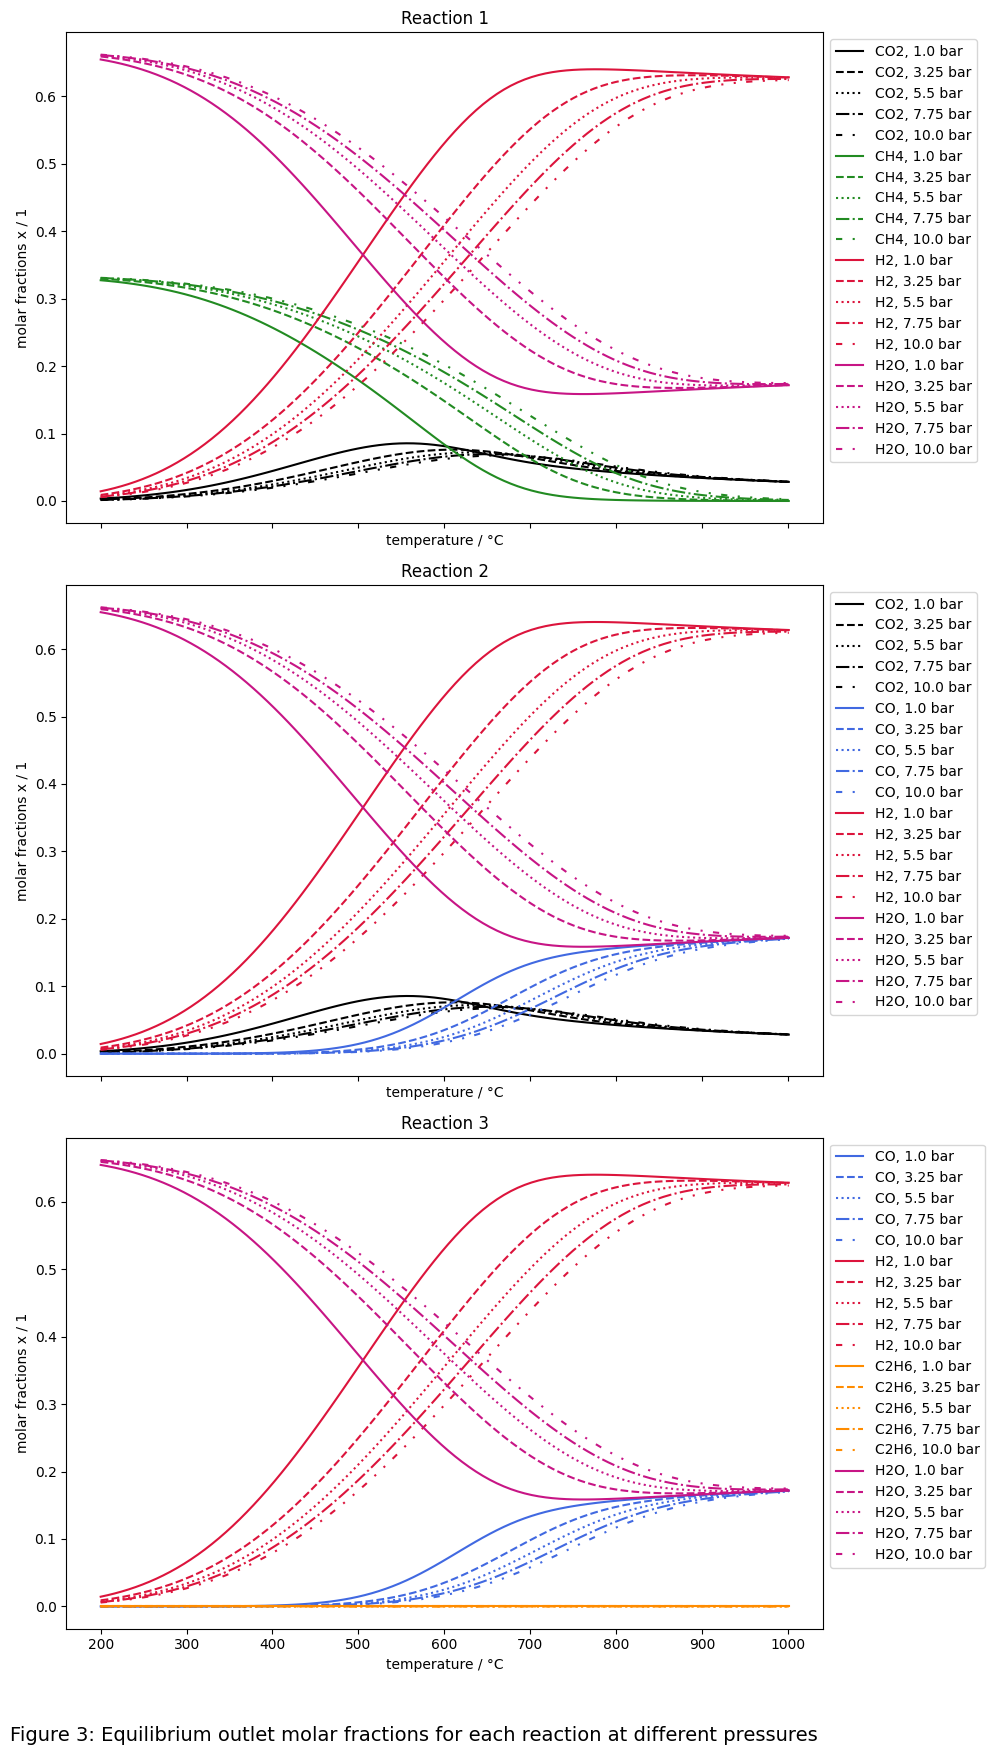

In [10]:
xi = np.stack([xi_0, xi_1, xi_2], axis=0)  # ✅ Fix: create xi from xi_0, xi_1, xi_2
xi_T = xi  # or skip this if not needed

delta_n1 = np.tensordot(N_11, xi_T, axes=(1, 0))  # Now this line works!
...
#xi = np.stack([xi_0, xi_1, xi_2], axis=0)  # Shape: (3, p, T)
#xi_T = np.transpose(xi, (2, 0, 1))                          # transpose xi to Shape (3, n_p, n_T)
#delta_n1 = np.tensordot(N_11, xi_T, axes=(1, 0))            # Matrixmultiplication, Shape: (n_components, p, T)

N_11_inv = np.linalg.inv(N_11)
M = N_21 @ N_11_inv                                         # do matrixmultiplication
delta_n2 = np.tensordot(M, delta_n1, axes=(1, 0))
delta_n = np.vstack((delta_n1,delta_n2))                    # stack out vectors together, Shape: (6, 5, 100)

n_in_vec = np.tile(n_in[:, np.newaxis, np.newaxis], (1, len(p), len(T)))  # Shape: (6, 5, 100)
n_out = n_in_vec + delta_n 
x_out = n_out / np.sum(n_out, axis=0, keepdims=True)        # Shape: (6, 5, 100)

fig, axes = plt.subplots(3, 1, figsize=(10, 18), sharex=True)
axes = axes.flatten()

species_per_rxn = [
    [0, 2, 3, 5],  # Reaction 1
    [0, 1, 3, 5],  # Reaction 2
    [1, 3, 4, 5],  # Reaction 3
]

for rxn_idx, ax in enumerate(axes):                                # plot molar fractions for each reaction  
    for sp in species_per_rxn[rxn_idx]:                            # plot molar fractions for each component
        species_name = components[sp]                              # get species name from list at beginning of notebook
        color = colors[sp]                                         # get colors from list at beginning
        for j, pressure in enumerate(p):                           # loop over pressures
            linestyle = linestyles[j % len(linestyles)]            # get linestyles 
            label = f"{species_name}, {pressure} bar"              # set label
            ax.plot(T - 273.15, x_out[sp, j, :], label=label,
                    color=color, linestyle=linestyle)
    ax.set_title(f"Reaction {rxn_idx + 1}")
    ax.set_xlabel("temperature / °C")                              # add x-axis label
    ax.set_ylabel("molar fractions x / 1")                         # add y-axis label
    ax.legend(bbox_to_anchor=(1,1), loc="upper left")
fig.text(0.01, 0.03, "Figure 3: Equilibrium outlet molar fractions for each reaction at different pressures", fontsize=14)
plt.tight_layout(rect=[0, 0.06, 1, 1])                             # adjust layout to fit caption
plt.savefig("A2_Molarfractions.png",dpi=300, bbox_inches='tight')  # save figure to local path
plt.show()   

### 6.3 Discussion of the equilibrium molar fractions at the outlet

Figure 3 shows the outlet molar fractions of key components at equilibrium for independent reactions, displayed as a function of temperature for multiple fixed pressures.  The subplots provide a direct comparison of how the product and reactant distributions vary with thermal conditions under chemical equilibrium.

In Reaction 1, the predicted trends are clear: the molar fraction of CH₄ declines with temperature, while CO₂ and H₂ rise.  This behavior reflects the exothermic nature of the methanation reaction, in which higher temperatures restrict product formation.  Higher pressures result in increased CH₄ mole fractions throughout all temperature ranges, supporting the previously mentioned pressure-enhanced conversion.

In Reaction 2, the outlet mole fractions of CO and H₂O increase with temperature, whereas CO₂ and H₂ decrease.  This pattern relates to the endothermic character of the reverse water-gas shift reaction, in which increased thermal input shifts the reaction towards products.  Although the stoichiometric mole balance is pressure-neutral, the graphs show that outlet compositions vary slightly across pressure levels.  This small pressure dependency provides confidence in the hypothesis that equilibrium behavior in Reaction 2 is influenced not only by its stoichiometry, but also by how the reactions are coupled and the system's initial composition.

Reaction 3 favours the production of C₂H₆ at lower temperatures and higher pressures, as shown by a decreasing mole fraction with rising temperature and an upward shift with pressure.  The availability of CO, which acts as a precursor in Reaction 2, also influences the extent of ethane production.  The CO and H₂ mole fractions reveal non-monotonic behavior, indicating their functions as both reactants and intermediates in the coupled system.

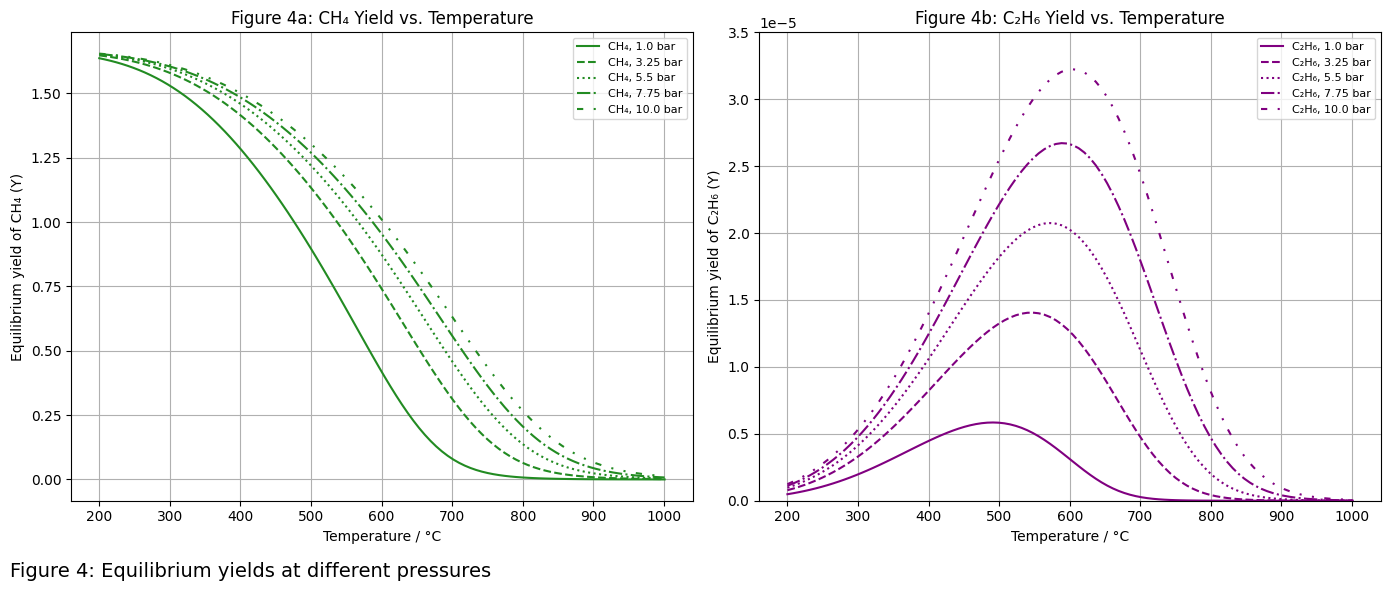

In [12]:

# Initialize arrays to store yield data
Yields_CH4 = np.empty((len(p), len(T)))                           
Yields_C2H6 = np.empty((len(p), len(T)))

# Compute yields from mole fractions
for i in range(len(p)):
    for j in range(len(T)):
        n_out_ij = x_out[:, i, j] * np.sum(n_in)                  # outlet molar flow rate [mol/s]
        Yields_CH4[i, j] = n_out_ij[2] / n_in[0]                  # CH₄ yield w.r.t CO₂
        Yields_C2H6[i, j] = n_out_ij[4] / n_in[0]                 # C₂H₆ yield w.r.t CO₂
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)  # Create side-by-side subplots

# Left subplot: CH₄ Yield
for i, pressure in enumerate(p):
    linestyle = linestyles[i % len(linestyles)]
    axes[0].plot(T - 273.15, Yields_CH4[i], label=f"CH₄, {pressure} bar",
                 color='forestgreen', linestyle=linestyle)

axes[0].set_xlabel("Temperature / °C")
axes[0].set_ylabel("Equilibrium yield of CH₄ (Y)")
axes[0].set_title("Figure 4a: CH₄ Yield vs. Temperature")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Right subplot: C₂H₆ Yield
for i, pressure in enumerate(p):
    linestyle = linestyles[i % len(linestyles)]
    axes[1].plot(T - 273.15, Yields_C2H6[i], label=f"C₂H₆, {pressure} bar",
                 color='purple', linestyle=linestyle)

axes[1].set_xlabel("Temperature / °C")
axes[1].set_ylabel("Equilibrium yield of C₂H₆ (Y)")
axes[1].set_title("Figure 4b: C₂H₆ Yield vs. Temperature")
axes[1].set_ylim(0, 0.000035)  # Adjust scale for ethane yield
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout(rect=[0, 0.06, 1, 1])     
fig.text(0.01, 0.03, "Figure 4: Equilibrium yields at different pressures", fontsize=14)
plt.savefig("A2_Yield_CH4_C2H6_SideBySide.png", dpi=300, bbox_inches='tight')  # Save figure
plt.show()


### 6.4 Discussion of the equilibrium yields

Figure 4a and 4b shows the estimated equilibrium yields of CH₄ and C₂H₆, normalized to the inlet quantity of CO₂, at various temperatures and pressures.  This graph illustrates the efficiency of converting carbon from CO₂ into hydrocarbon products under various operating conditions.

The yield of CH₄ is highly dependent on temperature and pressure.  It declines considerably with increasing temperature, indicating an unfavorable equilibrium shift for this exothermic reaction with increased thermal input.  At temperatures exceeding 400 °C, methane production decreases significantly.  Increasing system pressure leads to increased CH₄ yields and reduced gas-phase mole numbers, which promotes product formation.  These trends indicate a preference for low-temperature, high-pressure conditions to maximize CH₄ formation.

In comparison, the yield of C₂H₆ remained almost constant across the whole temperature range for all pressures.  This plateau-like behavior indicates that temperature has only a slight influence on the equilibrium position for ethane production in the simulated window.  Despite being exothermic, the reaction does not exhibit the predicted thermal suppression.  The reason is the reaction's dependency on CO, which is produced in a temperature-sensitive process.  The balance between enhanced CO availability at higher temperatures and the thermodynamic restrictions of ethane synthesis appears to keep the yield stable throughout conditions. Therefore, the flat profile does not indicate thermodynamic neutrality, but rather compensatory interactions between coupled reactions.

## 7. Conclusion 

This parametric study shows how different reaction conditions like temperature, pressure, and the ratio of hydrogen to CO₂ affect the conversion of carbon dioxide into hydrocarbons such as methane and ethane. The results indicate that lower temperatures favor the formation of methane, while higher temperatures encourage the production of carbon monoxide through the reverse water-gas shift reaction. Changes in pressure and gas composition also play an important role in determining how much CO₂ is converted and which products are formed. Understanding these effects is very useful for industries that want to use CO₂ as a raw material to make fuels and chemicals. By carefully choosing the operating conditions, companies can improve how well the process works and increase the amount of valuable products made. This approach can help reduce the amount of CO₂ released into the atmosphere by recycling it into useful substances. Overall, this study provides important guidance for designing industrial processes that are both more efficient and better for the environment.

For example, companies working in synthetic fuel production, chemical manufacturing, and even power plants using carbon capture technology can apply these insights. By adjusting operating conditions, they can make the process more efficient and increase the amount of desired products.

This not only helps reduce greenhouse gas emissions but also supports the idea of recycling CO₂ instead of releasing it into the atmosphere. In the long run, such processes could play a key role in cleaner energy solutions and more sustainable industrial practices.

## 8. References

1) Cengel, Y. A., & Boles, M. A. (Year of latest edition). Thermodynamics: An Engineering Approach. McGraw-Hill Education.

2) Kuo, J. (Year of latest edition). Chemistry, Thermodynamics, and Reaction Kinetics for Environmental Engineers. CRC Press.

3) Van Zeggeren, F., & Storey, S. H. (1970). The Computation of Chemical Equilibria. Cambridge University Press.

4) Levenspiel, O. (Year of latest edition). Chemical Reaction Engineering. John Wiley & Sons.

5) Linstrom, P. J., & Mallard, W. G. (2001). The NIST Chemistry WebBook: A Chemical Data Resource on the Internet. Journal of Chemical & Engineering Data, 46(5), 1059-1063.

6) NIST Standard Reference Database 69 (NIST Chemistry WebBook). National Institute of Standards and Technology. (https://webbook.nist.gov/chemistry/)

7) McBride, B. J., Zehe, M. J., & Gordon, S. (2002). NASA Glenn coefficients for calculating thermodynamic properties of individual species (NASA/TP-2002-211556). NASA Glenn Research Center. (https://www.researchgate.net/publication/24316861_NASA_Glenn_coefficients_for_calculating_thermodynamic_properties_of_individual_species)

8) Gordon, S., & McBride, B. J. (1996). Computer Program for Calculation of Complex Chemical Equilibrium Compositions and Applications. Part II: Users Manual and Program Description (NASA RP-1311, Part 2). NASA Lewis Research Center. (http://www.lpre.de/resources/software/RP-1311-P2.pdf)

9) Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cortés, D., ... & van der Walt, S. J. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. Nature Methods, 17(3), 261-272., https://docs.scipy.org/doc/scipy-1.13.0/reference/generated/scipy.optimize.root.html)

10) Best, S., Becker, D., Schulz, D. (2016). Power-to-Gas - Funktionsweise, Technologien und Anwendungen.  DOI: 10.24405/13866